Intro to Regression with Neural Network in TensorFlow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


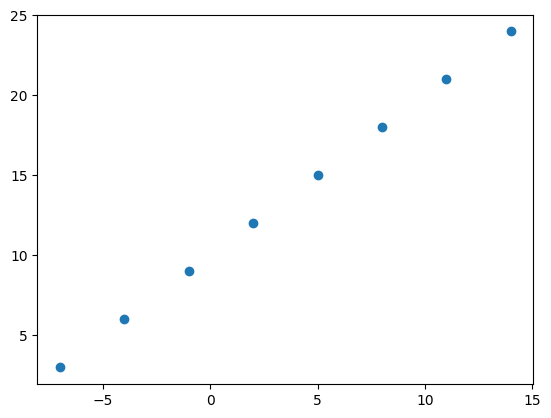

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

plt.scatter(X, y)
plt.show()

In [ ]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

Input and output shapes

In [ ]:
#Create demo tensor for housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [ ]:
X[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [ ]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [ ]:
X[0].ndim

0

In [ ]:
#Turn our Numpy arrays into tensors with dtype float32
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

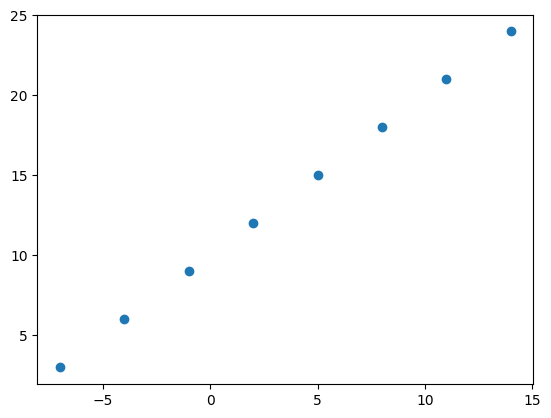

In [ ]:
plt.scatter(X, y)

##Steps in modelling with TensorFlow

1.Creating a model - define the input and output layers, as well the hidden layers of a deep learning model.  
2.Compiling a model - define the loss function (in other words, the function which tells our model how wrong it is) and optimizer (tells our model how to improve the patterns its learning) and evaluation metrics (what we can use to interpret the performance of our model).  
3.Fitting a model - letting the model try to find patterns between X & y (features and labels).  

In [ ]:
tf.random.set_seed(42)

# 1. Create a model using the Sequantial API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),#stochastic gradient descent
              metrics=["mae"])
# 3. Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - loss: 18.1539 - mae: 18.1539
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 17.8726 - mae: 17.8726
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 17.5914 - mae: 17.5914
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 17.3101 - mae: 17.3101
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 17.0289 - mae: 17.0289


In [ ]:
tf.expand_dims(X, axis=-1)

<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
array([[-7.],
       [-4.],
       [-1.],
       [ 2.],
       [ 5.],
       [ 8.],
       [11.],
       [14.]], dtype=float32)>

In [ ]:
tf.expand_dims(X, axis=0)

<tf.Tensor: shape=(1, 8), dtype=float32, numpy=array([[-7., -4., -1.,  2.,  5.,  8., 11., 14.]], dtype=float32)>

In [ ]:
#Check out X and y
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
#Try and make prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[-12.998183]], dtype=float32)

In [ ]:
y_train_pred = model.predict(tf.expand_dims(X, axis=-1))

y_train_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


array([[  5.4051347 ],
       [  3.1047196 ],
       [  0.80430496],
       [ -1.4961098 ],
       [ -3.7965248 ],
       [ -6.0969396 ],
       [ -8.397354  ],
       [-10.697769  ]], dtype=float32)

In [ ]:
for x_val, y_true, y_pred in zip(X, y, y_train_pred):
    print(f"X: {x_val.numpy():>5.1f} | True y: {y_true.numpy():>5.1f} | Predicted y: {y_pred[0]:>8.3f} | Error: {abs(y_true.numpy() - y_pred[0]):>8.3f}")

X:  -7.0 | True y:   3.0 | Predicted y:    5.405 | Error:    2.405
X:  -4.0 | True y:   6.0 | Predicted y:    3.105 | Error:    2.895
X:  -1.0 | True y:   9.0 | Predicted y:    0.804 | Error:    8.196
X:   2.0 | True y:  12.0 | Predicted y:   -1.496 | Error:   13.496
X:   5.0 | True y:  15.0 | Predicted y:   -3.797 | Error:   18.797
X:   8.0 | True y:  18.0 | Predicted y:   -6.097 | Error:   24.097
X:  11.0 | True y:  21.0 | Predicted y:   -8.397 | Error:   29.397
X:  14.0 | True y:  24.0 | Predicted y:  -10.698 | Error:   34.698


In [ ]:
tf.reduce_mean(tf.abs(y - tf.squeeze(y_train_pred)))

<tf.Tensor: shape=(), dtype=float32, numpy=16.747600555419922>

Improving our model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - loss: 9.7807 - mae: 9.7807
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.6482 - mae: 9.6482
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.5157 - mae: 9.5157
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.3832 - mae: 9.3832
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9.2507 - mae: 9.2507
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.1182 - mae: 9.1182
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8.9857 - mae: 8.9857
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.8532 - mae: 8.8532
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 8.7207 - mae: 8.7207
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 8.5882 - mae: 8.5882
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 8.4557 - mae: 8.4557
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.3232 - mae: 8.3232
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/st

In [ ]:
# Remind ourselves of the data
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [ ]:
# Let's see if our model's prediction has improved
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[30.167559]], dtype=float32)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 12.6219 - mae: 12.6219
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 12.0904 - mae: 12.0904
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.5574 - mae: 11.5574
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 11.0236 - mae: 11.0236
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 10.4731 - mae: 10.4731
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 9.9102 - mae: 9.9102
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.3445 - mae: 9.3445
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 8.7768 - mae: 8.7768
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 8.1713 - mae: 8.1713
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 7.5219 - mae: 7.5219
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 6.8296 - mae: 6.8296
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 6.0796 - mae: 6.0796
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[32.840027]], dtype=float32)

In [ ]:
X_test = tf.constant([[-7.0], [-4.0], [-1.0], [2.0], [5.0], [8.0], [11.0], [14.0], [17.0]])

y_test_pred = model.predict(X_test)

for x_val, pred in zip(tf.squeeze(X_test), y_test_pred):
    true_y = x_val + 10
    print(f"X: {x_val.numpy():>5.1f} | True y: {true_y.numpy():>5.1f} | Predicted: {pred[0]:>8.3f} | Error: {abs(true_y.numpy() - pred[0]):>8.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
X:  -7.0 | True y:   3.0 | Predicted:    3.239 | Error:    0.239
X:  -4.0 | True y:   6.0 | Predicted:    2.133 | Error:    3.867
X:  -1.0 | True y:   9.0 | Predicted:    1.025 | Error:    7.975
X:   2.0 | True y:  12.0 | Predicted:    4.721 | Error:    7.279
X:   5.0 | True y:  15.0 | Predicted:   10.345 | Error:    4.655
X:   8.0 | True y:  18.0 | Predicted:   15.969 | Error:    2.031
X:  11.0 | True y:  21.0 | Predicted:   21.592 | Error:    0.592
X:  14.0 | True y:  24.0 | Predicted:   27.216 | Error:    3.216
X:  17.0 | True y:  27.0 | Predicted:   32.840 | Error:    5.840


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step - loss: 11.6555 - mae: 11.6555
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.0283 - mae: 11.0283
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.4081 - mae: 10.4081
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 9.7722 - mae: 9.7722
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 9.1144 - mae: 9.1144
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.4225 - mae: 8.4225
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.6794 - mae: 7.6794
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.8819 - mae: 6.8819
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 6.0272 - mae: 6.0272
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5.1100 - mae: 5.1100
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.2966 - mae: 4.2966
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.1617 - mae: 4.1617
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [ ]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[31.404472]], dtype=float32)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step - loss: 13.9949 - mae: 13.9949
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 13.5148 - mae: 13.5148
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 13.0361 - mae: 13.0361
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 12.5563 - mae: 12.5563
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 12.0729 - mae: 12.0729
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 11.5834 - mae: 11.5834
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 11.0853 - mae: 11.0853
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 10.5760 - mae: 10.5760
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 10.0529 - mae: 10.0529
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9.5133 - mae: 9.5133
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8.9545 - mae: 8.9545
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.3736 - mae: 8.3736
Epoch 13/100
1/1 ━━━━━━━━━━━

In [ ]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[28.909847]], dtype=float32)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 13.2481 - mae: 13.2481
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 13.1826 - mae: 13.1826
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 13.1171 - mae: 13.1171
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 13.0515 - mae: 13.0515
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 12.9859 - mae: 12.9859
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 12.9202 - mae: 12.9202
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 12.8545 - mae: 12.8545
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 12.7888 - mae: 12.7888
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 12.7229 - mae: 12.7229
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 12.6570 - mae: 12.6570
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 12.5911 - mae: 12.5911
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 12.5251 - mae: 12.5251
Epoch 13/100
1/1 ━━━━━━━━

In [ ]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[19.149021]], dtype=float32)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 14.5573 - mae: 14.5573
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 13.9595 - mae: 13.9595
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 13.3608 - mae: 13.3608
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 12.7774 - mae: 12.7774
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 12.3367 - mae: 12.3367
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 11.9410 - mae: 11.9410
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 11.5515 - mae: 11.5515
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 11.1657 - mae: 11.1657
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 10.7789 - mae: 10.7789
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 10.3911 - mae: 10.3911
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.9986 - mae: 9.9986
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 9.6020 - mae: 9.6020
Epoch 13/100
1/1 ━━━━━━━━━━━━━

In [ ]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[27.02591]], dtype=float32)

## Evaluating a model

In [ ]:
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

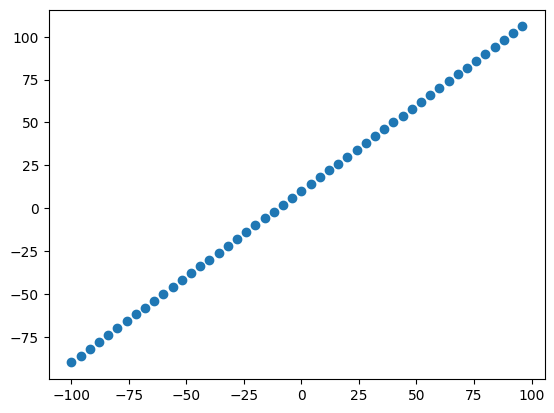

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X, y)

In [ ]:
len(X), len(y)

(50, 50)

In [ ]:
X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

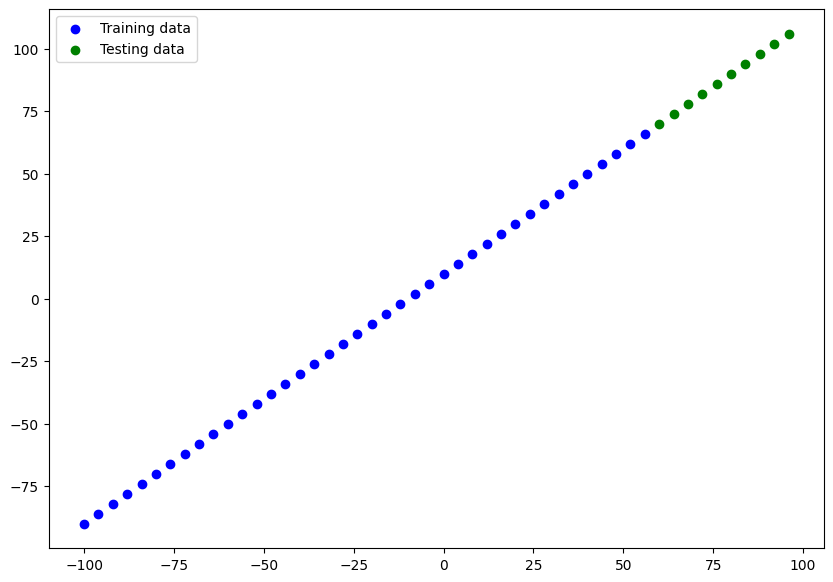

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", label="Training data")
plt.scatter(X_test, y_test, c="g", label="Testing data")
plt.legend()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [ ]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=100, verbose=0)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1])
])
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import plot_model


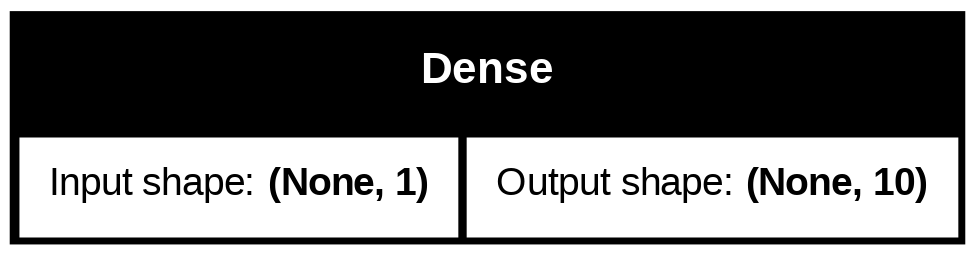

In [ ]:
plot_model(model, show_shapes=True)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, epochs=100, verbose=0)

In [ ]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

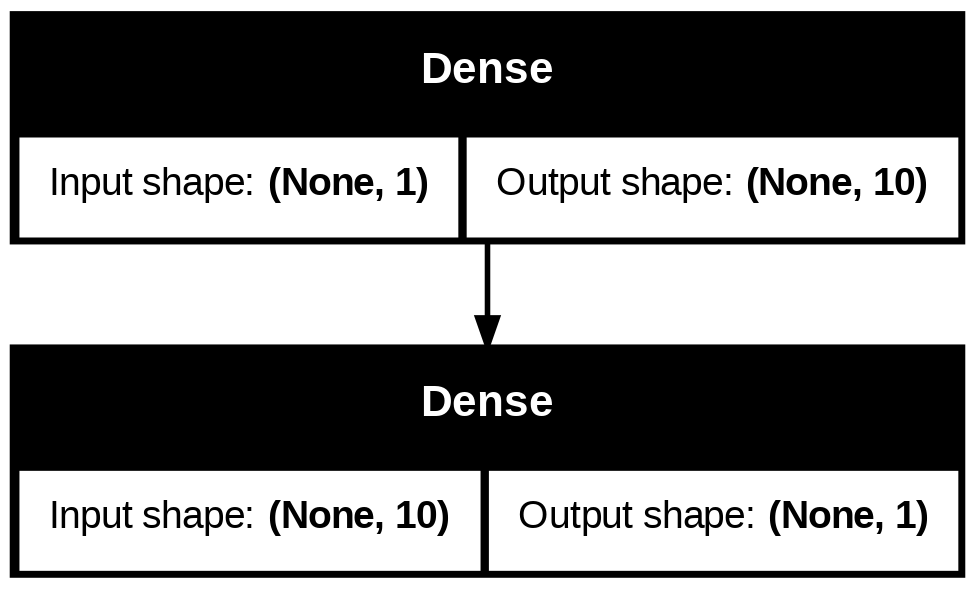

In [ ]:
plot_model(model=model, show_shapes=True)

In [ ]:
tf.random.set_seed(42)

model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(20, name="hidden_layer_1"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")
model2.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model2.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.fit(X_train, y_train, epochs=100, verbose=0)

In [ ]:
model2.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263 (1.03 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

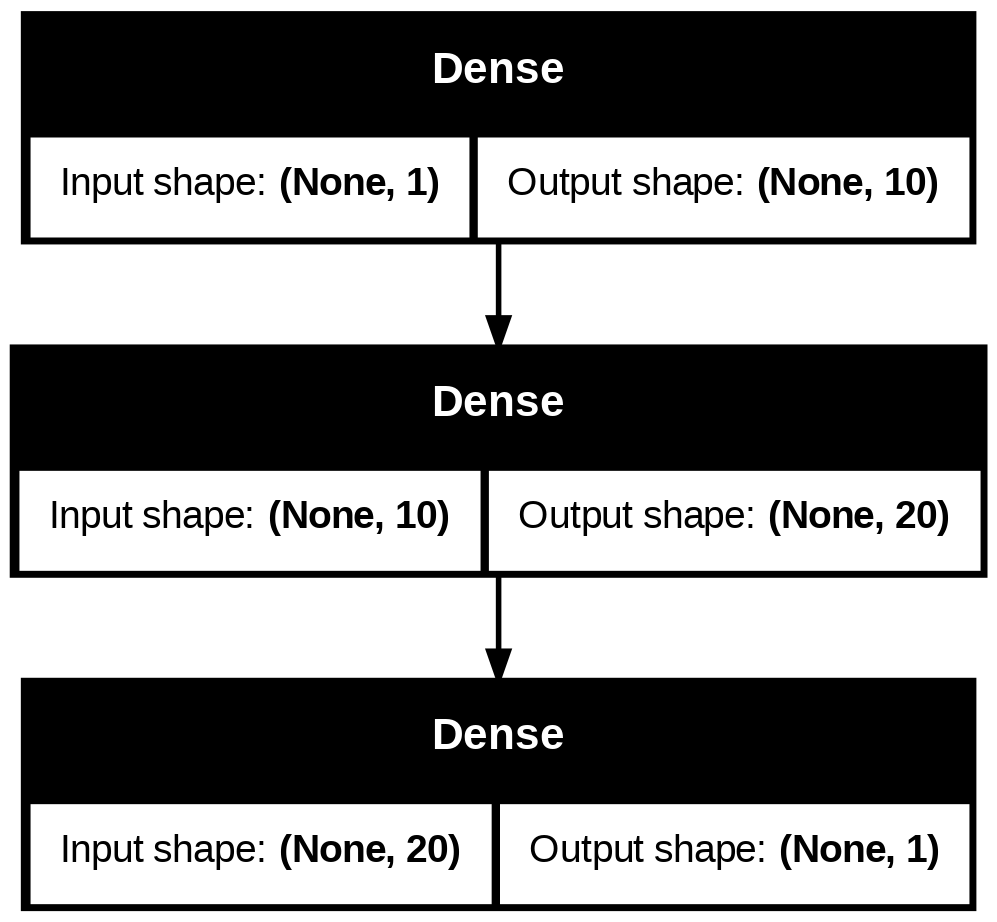

In [ ]:
plot_model(model=model2, show_shapes=True)

#Visualize Predictions

In [ ]:
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[42.924324],
       [45.675762],
       [48.427208],
       [51.178654],
       [53.930096],
       [56.68154 ],
       [59.43298 ],
       [62.18442 ],
       [64.935875],
       [67.68732 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

⚓ Plotting Function

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  plt.legend()
  plt.show()

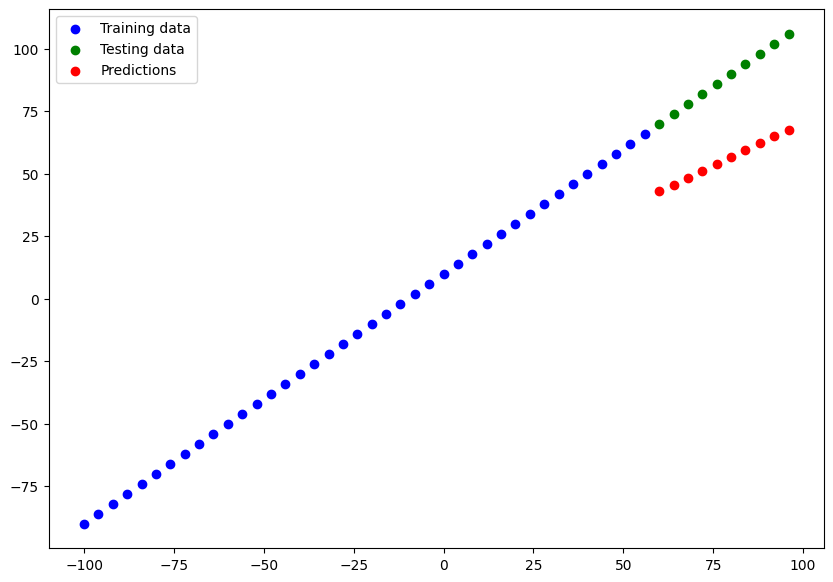

In [ ]:
plot_predictions(predictions=y_pred)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


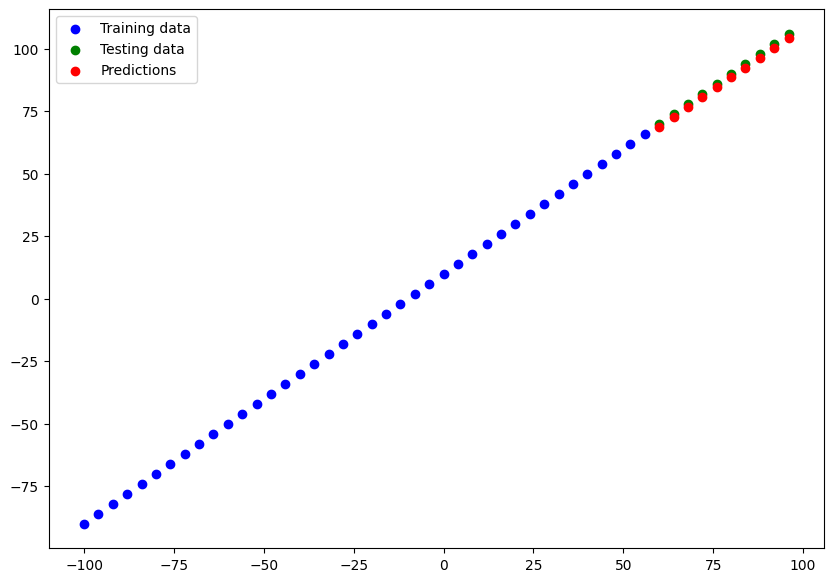

In [ ]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_3")

model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

model_3.fit(X_train, y_train, epochs=200, verbose=0)

y_pred_3 = model_3.predict(X_test)

plot_predictions(predictions=y_pred_3)

In [ ]:
model_3.summary()

Model: "model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

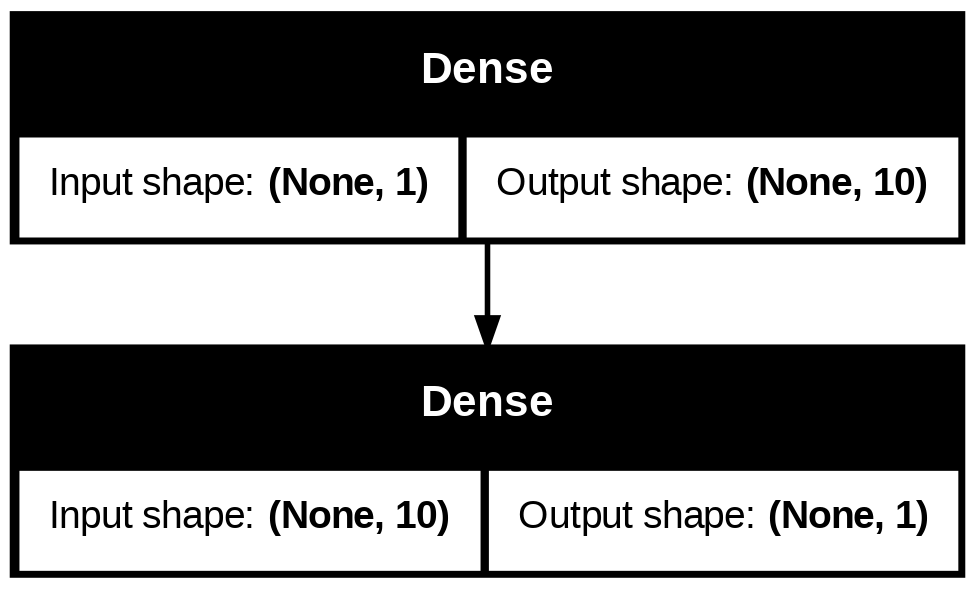

In [ ]:
plot_model(model_3, show_shapes=True)

In [ ]:
y_pred_3

array([[ 68.89151 ],
       [ 72.82012 ],
       [ 76.74874 ],
       [ 80.67735 ],
       [ 84.60597 ],
       [ 88.534584],
       [ 92.4632  ],
       [ 96.39182 ],
       [100.32044 ],
       [104.24905 ]], dtype=float32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


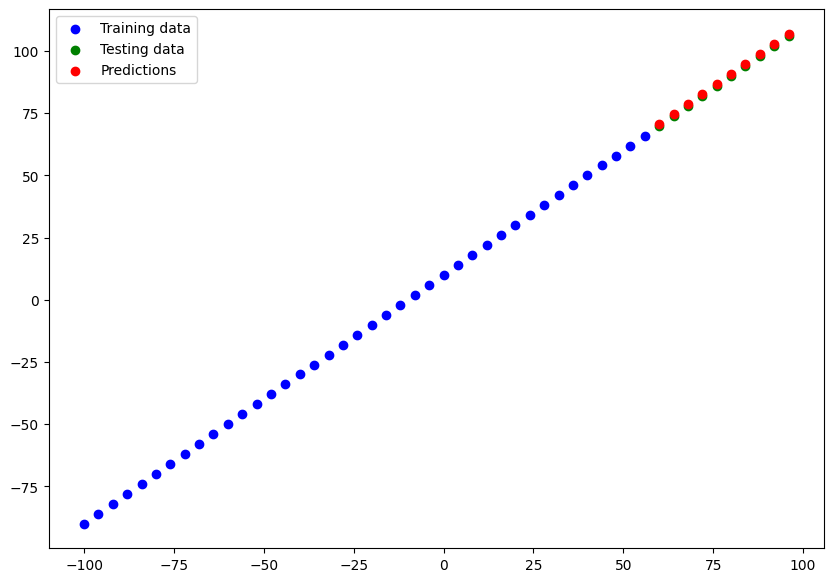

In [ ]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
], name="model_4")

model_4.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

model_4.fit(X_train, y_train, epochs=500, verbose=0)

y_pred_4 = model_4.predict(X_test)

plot_predictions(predictions=y_pred_4)

In [ ]:
model_4.summary()

Model: "model_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

In [ ]:
model_4.get_weights()

[array([[1.0096226]], dtype=float32), array([9.994581], dtype=float32)]

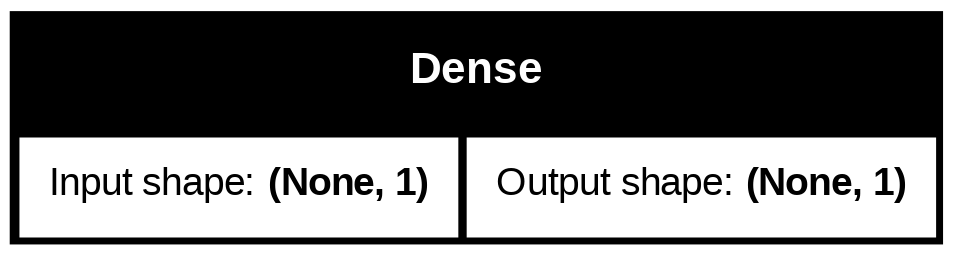

In [ ]:
plot_model(model_4, show_shapes=True)

In [ ]:
y_pred_4

array([[ 70.57194],
       [ 74.61043],
       [ 78.64892],
       [ 82.68741],
       [ 86.7259 ],
       [ 90.76439],
       [ 94.80288],
       [ 98.84137],
       [102.87986],
       [106.91835]], dtype=float32)

Evaluating our model's predictions with regression evaluation metrics

In [ ]:
model_4.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.7451 - mae: 0.7451


[0.7451438903808594, 0.7451438903808594]

In [ ]:
y_pred_4

array([[ 70.57194],
       [ 74.61043],
       [ 78.64892],
       [ 82.68741],
       [ 86.7259 ],
       [ 90.76439],
       [ 94.80288],
       [ 98.84137],
       [102.87986],
       [106.91835]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
mae_4 = tf.keras.metrics.MeanAbsoluteError()(y_test, tf.squeeze(y_pred_4))

mae_4

<tf.Tensor: shape=(), dtype=float32, numpy=0.7451438903808594>

In [ ]:
errors = tf.abs(tf.cast(y_test, dtype=tf.float32) - tf.squeeze(y_pred_4))

errors

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.57193756, 0.61042786, 0.64891815, 0.68740845, 0.72589874,
       0.76438904, 0.80287933, 0.8413696 , 0.8798599 , 0.9183502 ],
      dtype=float32)>

In [ ]:
tf.cast(y_test, dtype=tf.float32)- tf.squeeze(y_pred_4)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([-0.57193756, -0.61042786, -0.64891815, -0.68740845, -0.72589874,
       -0.76438904, -0.80287933, -0.8413696 , -0.8798599 , -0.9183502 ],
      dtype=float32)>

In [ ]:
mse_4 = tf.reduce_mean(
    tf.square(
        tf.cast(y_test, dtype=tf.float32) - tf.squeeze(y_pred_4)
        )
    )

mse_4

<tf.Tensor: shape=(), dtype=float32, numpy=0.5674617886543274>

In [ ]:
mse_4 = tf.metrics.MeanSquaredError()(
    tf.cast(y_test, dtype=tf.float32),
    tf.squeeze(y_pred_4)
)

mse_4

<tf.Tensor: shape=(), dtype=float32, numpy=0.5674617886543274>

In [ ]:
y_true = tf.cast(y_test, dtype=tf.float32)
y_pred = tf.squeeze(y_pred_4)

absolute_errors = tf.abs(y_true - y_pred)
squared_errors = tf.square(y_true - y_pred)

mae = tf.reduce_mean(absolute_errors)
mse = tf.reduce_mean(squared_errors)

absolute_errors, squared_errors, mae, mse

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.57193756, 0.61042786, 0.64891815, 0.68740845, 0.72589874,
        0.76438904, 0.80287933, 0.8413696 , 0.8798599 , 0.9183502 ],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([0.3271126 , 0.37262216, 0.42109478, 0.47253036, 0.52692896,
        0.5842906 , 0.64461523, 0.70790285, 0.7741535 , 0.8433671 ],
       dtype=float32)>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.7451438903808594>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.5674617886543274>)

In [ ]:
def mae(y_true, y_pred):

    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), dtype=tf.float32)

    return tf.reduce_mean(tf.abs(y_true - y_pred))


def mse(y_true, y_pred):

    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), dtype=tf.float32)

    return tf.reduce_mean(tf.square(y_true - y_pred))

In [ ]:
mae_4 = mae(y_test, y_pred_4)
mse_4 = mse(y_test, y_pred_4)

mae_4, mse_4

(<tf.Tensor: shape=(), dtype=float32, numpy=0.7451438903808594>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.5674617886543274>)

##Running experiments to improve our model

Build a model -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it -> tweak it -> fit it -> evalueate it -> ...

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

X = tf.range(-50, 50, 2, dtype=tf.float32)

noise = tf.random.normal(shape=X.shape, mean=0, stddev=40)

y = 0.3 * X ** 2 + 2 * X + 10 + noise

X[:10], y[:10]

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([-50., -48., -46., -44., -42., -40., -38., -36., -34., -32.],
       dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([673.09875, 571.495  , 565.5774 , 446.498  , 359.6776 , 368.4301 ,
        344.90707, 348.38834, 356.7773 , 264.75748], dtype=float32)>)

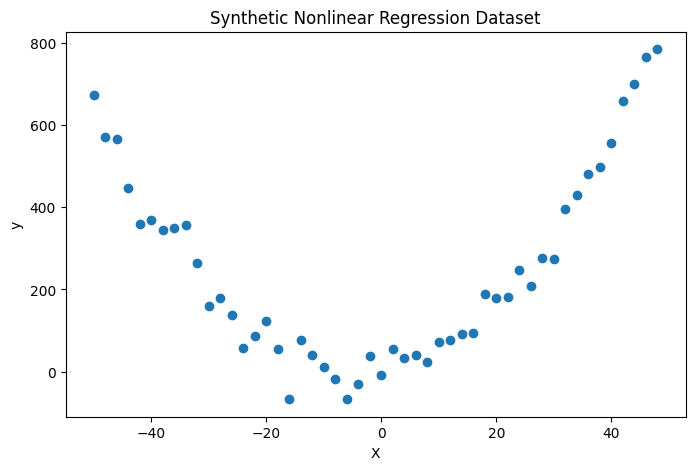

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Nonlinear Regression Dataset")
plt.show()

In [ ]:
X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

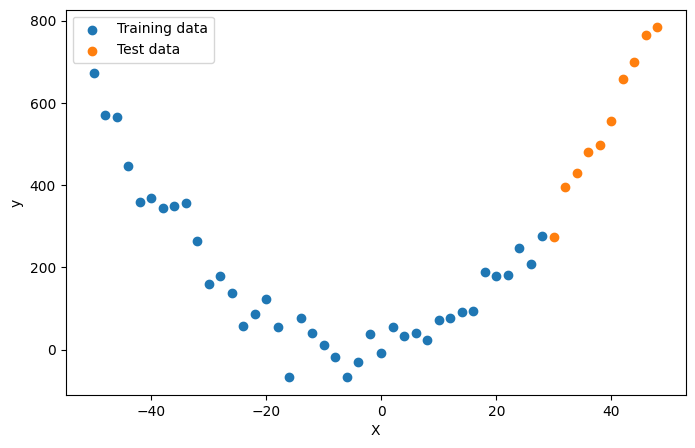

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Training data")
plt.scatter(X_test, y_test, label="Test data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(8, 5))
    plt.scatter(train_data, train_labels, label="Training data")
    plt.scatter(test_data, test_labels, label="Test data")

    if predictions is not None:
        plt.scatter(test_data, predictions, label="Predictions")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [ ]:
def mae(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), dtype=tf.float32)
    return tf.reduce_mean(tf.abs(y_true - y_pred))


def mse(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(tf.squeeze(y_pred), dtype=tf.float32)
    return tf.reduce_mean(tf.square(y_true - y_pred))


def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mae(y_true, y_pred).numpy(),
        "MSE": mse(y_true, y_pred).numpy()
    }

In [ ]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
], name='model_1')

model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['mae'])

history_1 = model_1.fit(X_train, y_train, epochs=200, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


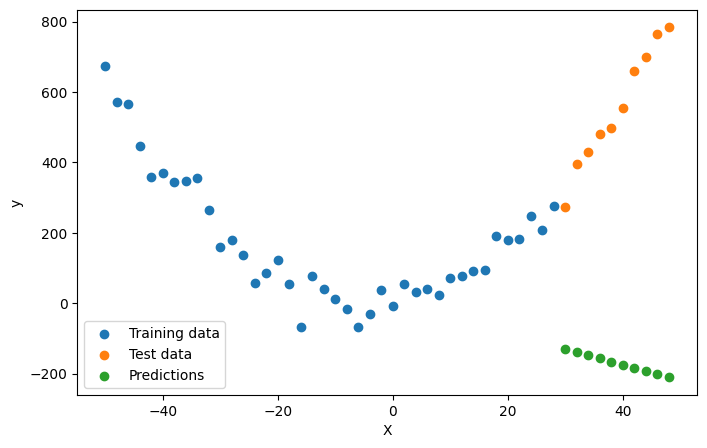

In [ ]:
y_pred_1 = model_1.predict(X_test)

plot_predictions(predictions=y_pred_1)

In [ ]:
evaluate_regression(y_test, y_pred_1)

{'MAE': np.float32(723.84125), 'MSE': np.float32(558541.6)}

In [ ]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=[1]),
    tf.keras.layers.Dense(1)
], name="model_2_hidden")

model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

history_2 = model_2.fit(X_train, y_train, epochs=300, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


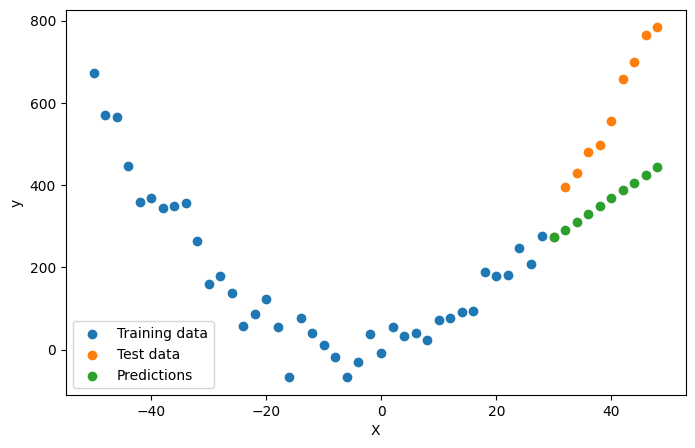

In [ ]:
y_pred_2 = model_2.predict(X_test)

plot_predictions(predictions=y_pred_2)

In [ ]:
evaluate_regression(y_test, y_pred_2)

{'MAE': np.float32(195.02031), 'MSE': np.float32(49424.055)}

In [ ]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=[1]),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
], name="model_3_deeper")

model_3.compile(
    loss=tf.keras.losses.Huber(delta=10.0),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    metrics=["mae"]
)

history_3 = model_3.fit(X_train, y_train, epochs=500, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


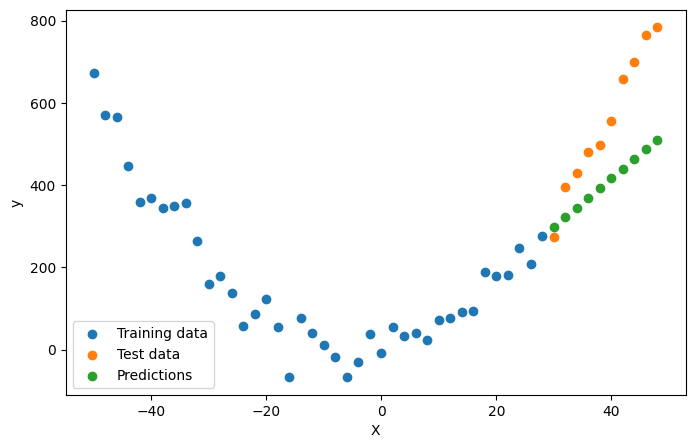

In [ ]:
y_pred_3 = model_3.predict(X_test)

plot_predictions(predictions=y_pred_3)

In [ ]:
evaluate_regression(y_test, y_pred_3)

{'MAE': np.float32(154.13315), 'MSE': np.float32(31086.219)}

In [ ]:
import pandas as pd
model_results = [
    ["model_1_linear", mae(y_test, y_pred_1).numpy(), mse(y_test, y_pred_1).numpy()],
    ["model_2_deep", mae(y_test, y_pred_2).numpy(), mse(y_test, y_pred_2).numpy()],
    ["model_3_deeper", mae(y_test, y_pred_3).numpy(), mse(y_test, y_pred_3).numpy()]
]
model_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
model_results


,model,mae,mse
0,model_1_linear,723.841248,558541.625000
1,model_2_deep,195.020309,49424.054688
2,model_3_deeper,154.133148,31086.218750


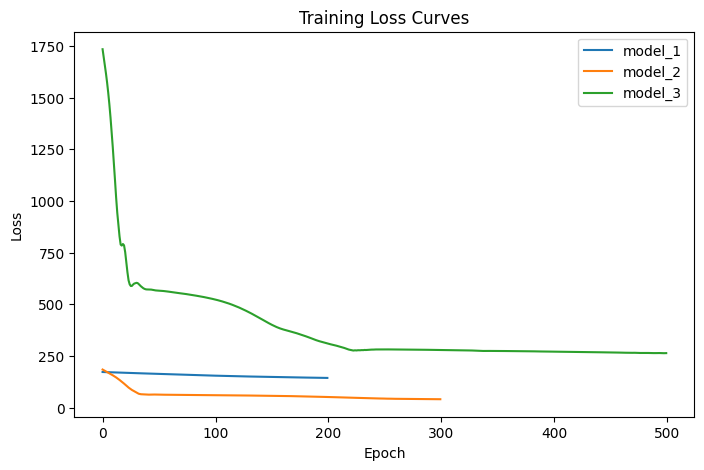

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_1.history["loss"], label="model_1")
plt.plot(history_2.history["loss"], label="model_2")
plt.plot(history_3.history["loss"], label="model_3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss Curves")
plt.show()

In [ ]:
indices = tf.range(len(X))
shuffled_indices = tf.random.shuffle(indices, seed=42)

X_shuffled = tf.gather(X, shuffled_indices)
y_shuffled = tf.gather(y, shuffled_indices)

train_size = int(len(X) * 0.8)

X_train_random = X_shuffled[:train_size]
y_train_random = y_shuffled[:train_size]
X_test_random = X_shuffled[train_size:]
y_test_random = y_shuffled[train_size:]

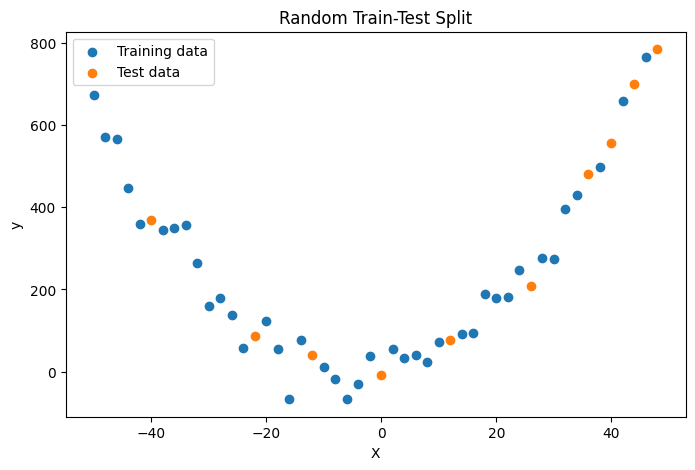

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train_random, y_train_random, label="Training data")
plt.scatter(X_test_random, y_test_random, label="Test data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Random Train-Test Split")
plt.show()

In [ ]:
def plot_predictions_random(train_data=X_train_random,
                            train_labels=y_train_random,
                            test_data=X_test_random,
                            test_labels=y_test_random,
                            predictions=None):

    plt.figure(figsize=(8, 5))
    plt.scatter(train_data, train_labels, label="Training data")
    plt.scatter(test_data, test_labels, label="Test data")

    if predictions is not None:
        plt.scatter(test_data, predictions, label="Predictions")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


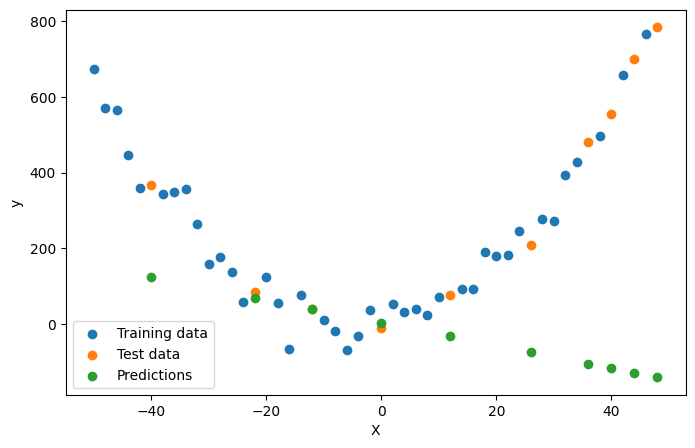

{'MAE': np.float32(367.45157), 'MSE': np.float32(248174.3)}

In [ ]:
tf.random.set_seed(42)

model_1_random = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
], name="model_1_random_linear")

model_1_random.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

history_1_random = model_1_random.fit(
    X_train_random,
    y_train_random,
    epochs=200,
    verbose=0
)

y_pred_1_random = model_1_random.predict(X_test_random)

plot_predictions_random(predictions=y_pred_1_random)

evaluate_regression(y_test_random, y_pred_1_random)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


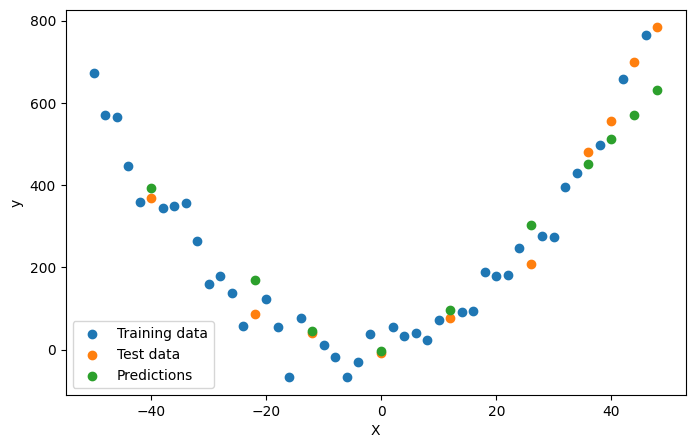

{'MAE': np.float32(58.028736), 'MSE': np.float32(5888.9775)}

In [ ]:
tf.random.set_seed(42)

model_2_random = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=[1]),
    tf.keras.layers.Dense(1)
], name="model_2_random_hidden")

model_2_random.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

history_2_random = model_2_random.fit(
    X_train_random,
    y_train_random,
    epochs=300,
    verbose=0
)

y_pred_2_random = model_2_random.predict(X_test_random)

plot_predictions_random(predictions=y_pred_2_random)

evaluate_regression(y_test_random, y_pred_2_random)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


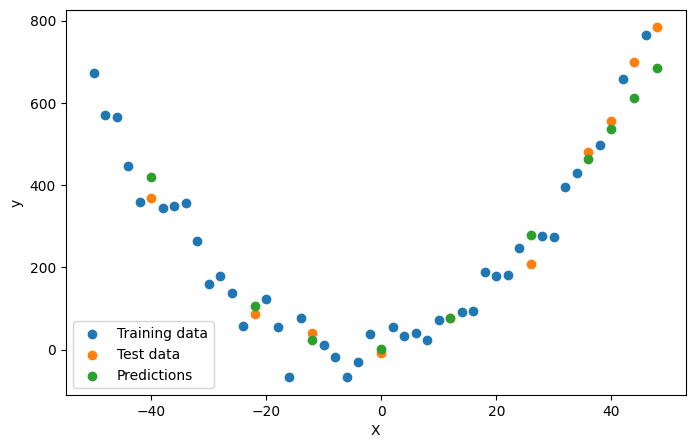

{'MAE': np.float32(39.48674), 'MSE': np.float32(2686.5989)}

In [ ]:
tf.random.set_seed(42)

model_3_random = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=[1]),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
], name="model_3_random_deeper")

model_3_random.compile(
    loss=tf.keras.losses.Huber(delta=10.0),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    metrics=["mae"]
)

history_3_random = model_3_random.fit(
    X_train_random,
    y_train_random,
    epochs=500,
    verbose=0
)

y_pred_3_random = model_3_random.predict(X_test_random)

plot_predictions_random(predictions=y_pred_3_random)

evaluate_regression(y_test_random, y_pred_3_random)

In [ ]:
model_results_random = [
    ["model_1_random_linear", mae(y_test_random, y_pred_1_random).numpy(), mse(y_test_random, y_pred_1_random).numpy()],
    ["model_2_random_hidden", mae(y_test_random, y_pred_2_random).numpy(), mse(y_test_random, y_pred_2_random).numpy()],
    ["model_3_random_deeper_huber", mae(y_test_random, y_pred_3_random).numpy(), mse(y_test_random, y_pred_3_random).numpy()]
]

results_random_df = pd.DataFrame(
    model_results_random,
    columns=["model", "MAE", "MSE"]
)

results_random_df

,model,MAE,MSE
0,model_1_random_linear,367.451569,248174.296875
1,model_2_random_hidden,58.028736,5888.977539
2,model_3_random_deeper_huber,39.486740,2686.598877


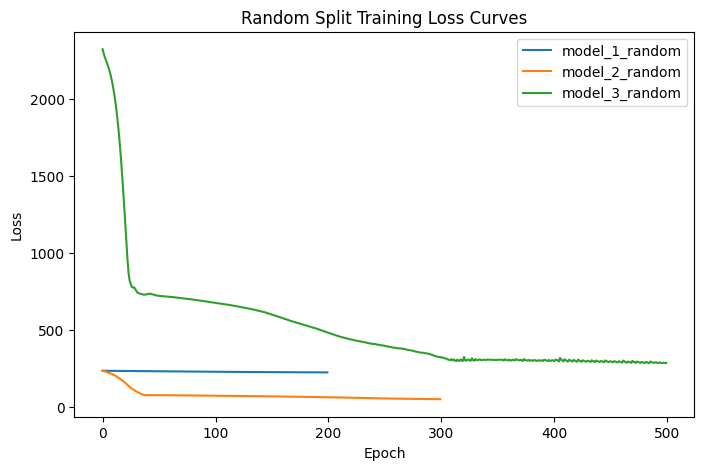

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_1_random.history["loss"], label="model_1_random")
plt.plot(history_2_random.history["loss"], label="model_2_random")
plt.plot(history_3_random.history["loss"], label="model_3_random")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Random Split Training Loss Curves")
plt.show()

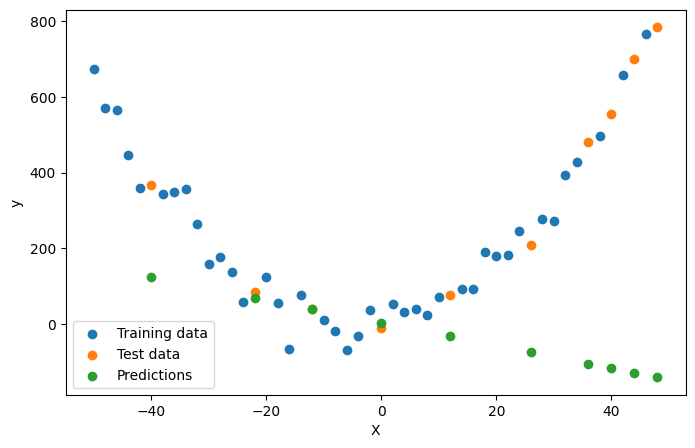

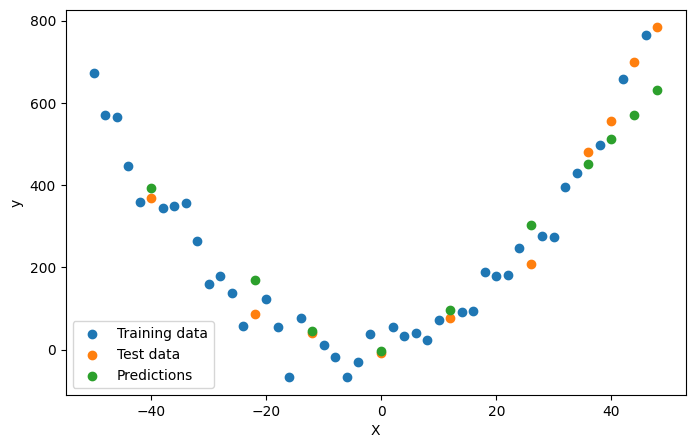

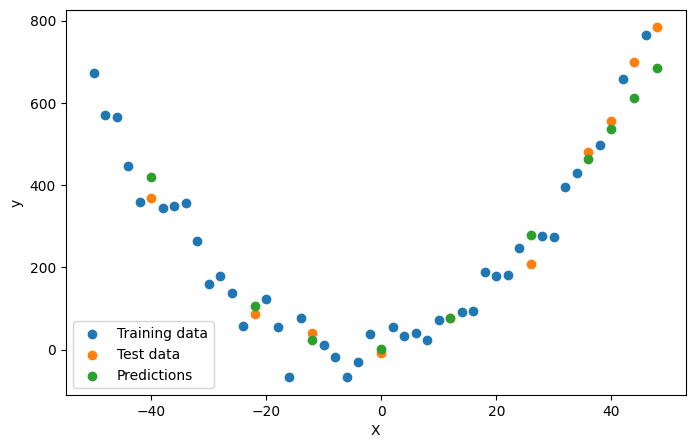

In [ ]:
plot_predictions_random(predictions=y_pred_1_random)
plot_predictions_random(predictions=y_pred_2_random)
plot_predictions_random(predictions=y_pred_3_random)

In [ ]:
model_2_random.summary()

Model: "model_2_random_hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293 (1.15 KB)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 196 (788.00 B)

## Tracking your experiments

-- TensorBoard  
--weight and biases

## Save & Load Models

--The SavedModel format  
--The HDF5 format

In [ ]:
model_2_random.save("model_2_random.h5")

In [ ]:
loaded_model_2_random = tf.keras.models.load_model("model_2_random.h5")

In [ ]:
loaded_model_2_random.summary()

Model: "model_2_random_hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99 (400.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
model_2_random_preds = model_2_random.predict(X_test_random)

loaded_model_2_random_preds = loaded_model_2_random.predict(X_test_random)

model_2_random_preds == loaded_model_2_random_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
model_2_random_preds.squeeze()

array([571.69196  , 511.79218  , 392.32947  ,  -3.2042737, 631.59125  ,
       451.8923   ,  96.83488  , 302.14264  ,  44.372036 , 168.64255  ],
      dtype=float32)

In [ ]:
loaded_model_2_random_preds.squeeze()

array([571.69196  , 511.79218  , 392.32947  ,  -3.2042737, 631.59125  ,
       451.8923   ,  96.83488  , 302.14264  ,  44.372036 , 168.64255  ],
      dtype=float32)

In [ ]:
!cp /content/model_2_random.h5 "/content/drive/MyDrive/Deep Learning"

In [ ]:
!ls "/content/drive/MyDrive/Deep Learning"

model_2_random.h5


## Larger Example